<a href="https://colab.research.google.com/github/LayanAltaweel1/Mining-project-/blob/main/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Read** **Dataset**

 In this step, we load the preprocessed dataset and use Label Encoding to convert categorical columns into numerical format to be ready for the mining tasks.

In [100]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Load the dataset
df = pd.read_csv('Preprocessed_dataset.csv')

# 2. Apply Label Encoding
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()

,FastingBloodSugar,HbA1c,FrequentUrination,Hypertension,ExcessiveThirst,UnexplainedWeightLoss,DiastolicBP,Smoking,SystolicBP,FamilyHistoryDiabetes,Diagnosis
0,0.759421,1.326985,0,0,0,0,73,1,-1.603098,1,1
1,1.416918,0.201700,0,0,0,0,99,0,1.208631,0,1
2,-0.199992,-1.663525,0,0,0,0,91,0,-0.587751,1,0
3,-1.400213,-0.264241,0,0,0,0,87,1,1.364839,1,0
4,-1.185447,-0.787228,0,0,0,0,69,0,1.208631,0,0


**Define Features and Target Variable**

 In this step, we define the features (X) which are the independent variables used for prediction, and the target (y) which is the dependent variable we want to predict (Diagnosis).

In [101]:
# Features (X): All columns except the target
X = df.drop('Diagnosis', axis=1)

# Target (y): The Diagnosis column (0 = No Diabetes, 1 = Diabetes)
y = df['Diagnosis']

print("Features (X) and Target (y) defined successfully.")

Features (X) and Target (y) defined successfully.


**Information Gain (Entropy)**

 In this step, we prepare to apply the Decision Tree algorithm using the Information Gain measure, which is represented by the Entropy criterion.

**Splitting Data into 80% Training and 20% Test**

 Before building the model, we must split our features (X) and target (y) into training and testing sets. We will use 80% of the data for training and 20% for testing.

In [102]:
from sklearn.model_selection import train_test_split

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Data successfully split into 80% training and 20% test.")

Data successfully split into 80% training and 20% test.


**Training Decision Tree (Entropy)**

 Now, we initialize the Decision Tree Classifier using the Entropy criterion and fit it to our training data.

In [103]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the model with Entropy
clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)

# Train the model
clf_entropy.fit(X_train, y_train)

print("Decision Tree model with Entropy has been trained.")


Decision Tree model with Entropy has been trained.


**Model Prediction**

 After training, we use the test set (X_test) to make predictions and see how the model performs on new data.

In [104]:
# Making predictions on the test set
y_pred = clf_entropy.predict(X_test)

print("Predictions completed.")

Predictions completed.


**Accuracy Score**

 We calculate the Accuracy to measure the percentage of correct predictions made by the model.

In [105]:
from sklearn.metrics import accuracy_score

# Calculate Accuracy
acc = accuracy_score(y_test, y_pred)

print(f"The Accuracy of the model is: {acc:.4f}")

The Accuracy of the model is: 0.9149


**Confusion Matrix Visualization**

 To visualize the performance, we create a Confusion Matrix. This helps us see how many cases were correctly or incorrectly classified for both "Diabetes" and "No Diabetes".

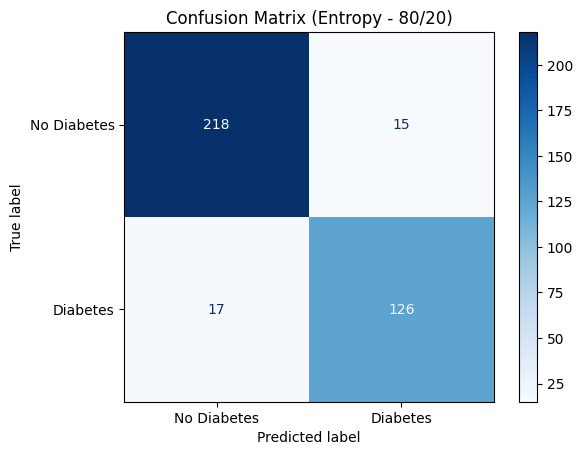

In [106]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Entropy - 80/20)")
plt.show()

**Confusion Matrix Analysis (Entropy – 80/20 Split)**

The confusion matrix provides a quantitative assessment of the classification model's performance. Based on the observed outcomes, it seems that:

 • Top-Left (True Negative – TN = 218): Correctly predicted as “No Diabetes” when the actual label was also “No Diabetes.”

 • Top-Right (False Positive – FP = 15): Incorrectly predicted as “Diabetes” when the actual label was “No Diabetes.”

 • Bottom-Left (False Negative – FN = 17): Incorrectly predicted as “No Diabetes” when the actual label was “Diabetes.”

 • Bottom-Right (True Positive – TP = 126): Correctly predicted as “Diabetes” when the actual label was also “Diabetes.”

**Build the Decision Tree Model Visualization (Entropy – 80/20):**

In [107]:
# Build the Decision Tree Model (Entropy – 80/20):
from sklearn.tree import DecisionTreeClassifier


clf_entropy_80 = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_entropy_80.fit(X_train, y_train)

print("Model clf_entropy_80 is now defined and trained.")


Model clf_entropy_80 is now defined and trained.


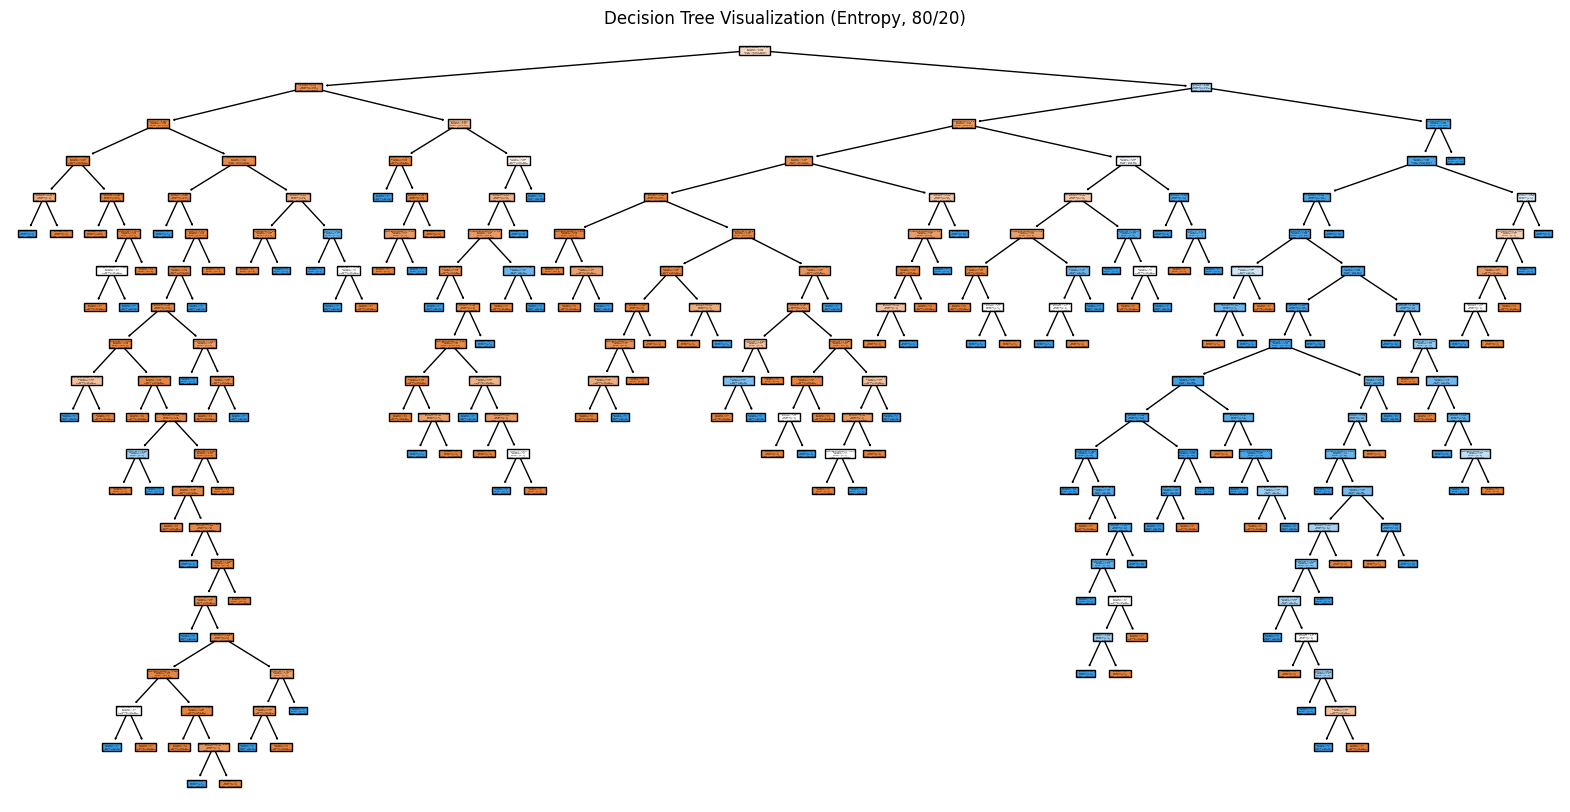

In [108]:
# Decision Tree Visualization (Entropy – 80/20 Split)
plt.figure(figsize=(20,10))
plot_tree(clf_entropy_80, filled=True, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'])
plt.title("Decision Tree Visualization (Entropy, 80/20)")
plt.show()


**Decision Tree Analysis (Entropy – 80/20 Split)**

This Decision Tree illustrates how the classification model predicts whether a patient is likely to have diabetes or not, based on medical attributes.

Each node in the tree represents a decision rule built using one of the dataset's features. The tree splits data step by step to reduce uncertainty (entropy) and improve prediction accuracy.

 • Initial Split:
The root node at the top of the tree represents the most significant medical feature with the highest discriminative power. In our model, this feature plays a major role in determining whether a patient is diabetic. It was chosen because it provided the maximum information gain.

 • Intermediate Nodes:
As we move down the tree, the model performs additional splits based on secondary medical features. Each split further narrows down the classification, refining the model's understanding of patient conditions.
 • Leaf Nodes:
At the bottom of the tree, leaf nodes represent the final classification outcomes:
  • Class 0: Non-diabetic patient
  • Class 1: Diabetic patient
  
Conclusion:
The model shows exceptional reliability with an accuracy of 91.49%.

The tree structure provides clear interpretability, showing how the model reached its decisions and which features were most influential in predicting diabetes.

**Model Evaluation Results (Entropy – 80/20 Split):**

In [109]:

# print the confusion matrix
print("Confusion Matrix:\n", cm)

# print the accuracy
print("\nAccuracy:", round(acc, 4))

# Error Rate (1 - Accuracy)
error_rate = 1 - acc
print("Error Rate:", round(error_rate, 4))

# Extract TN, FP, FN, TP
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

# Sensitivity (Recall)
sensitivity = TP / (TP + FN)
print("Sensitivity (Recall):", round(sensitivity, 4))

# Specificity
specificity = TN / (TN + FP)
print("Specificity:", round(specificity, 4))

# Precision
precision = TP / (TP + FP)
print("Precision:", round(precision, 4))


Confusion Matrix:
 [[218  15]
 [ 17 126]]

Accuracy: 0.9149
Error Rate: 0.0851
Sensitivity (Recall): 0.8811
Specificity: 0.9356
Precision: 0.8936


**Performance Metrics Analysis (Entropy – 80/20 Split):**

• Accuracy: 0.9149 The model correctly predicted approximately 91.49% of the test samples, showing high overall effectiveness.

• Error Rate: 0.0851 Only about 8.51% of the model's predictions were incorrect.

• Sensitivity (Recall): 0.8811 The model correctly identified 88.11% of the actual diabetic patients (Class 1), which is vital for medical diagnosis.

• Specificity: 0.9356 The model correctly identified 93.56% of non-diabetic patients (Class 0), demonstrating a strong ability to avoid false alarms.

• Precision: 0.8936 Out of all patients predicted as diabetic, 89.36% were truly diabetic, showing high reliability in positive predictions.



Results (Entropy – 80/20 Split):
The model demonstrates strong overall performance with high accuracy and balanced precision and recall.

• It performs slightly better at detecting non-diabetic patients (Specificity = 93.56%) than diabetic ones (Sensitivity = 88.11%).

• This indicates that while the classifier is generally reliable, there are 17 False Negatives (patients with diabetes who were missed).

• In a medical context, further tuning might be needed to reduce False Negatives to ensure all diabetic patients are properly diagnosed.

**Partitioning the Dataset into 70% Training and 30% Testing:**

In [110]:
# Splitting the data into 70% training and 30% test
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.30, random_state=42)

print("Data successfully split into 70% training and 30% test.")

Data successfully split into 70% training and 30% test.


**Build and Train the Decision Tree Model (Entropy – 70/30):**

In [111]:
# Initialize and train the model using Entropy (Information Gain)
clf_entropy_70 = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_entropy_70.fit(X_train_70, y_train_70)

# Predictions and Accuracy
y_pred_70 = clf_entropy_70.predict(X_test_70)
acc_70 = accuracy_score(y_test_70, y_pred_70)

print(f"The Accuracy for 70/30 split is: {acc_70:.4f}")


The Accuracy for 70/30 split is: 0.9043


**Generate the Confusion Matrix (Entropy – 70/30):**

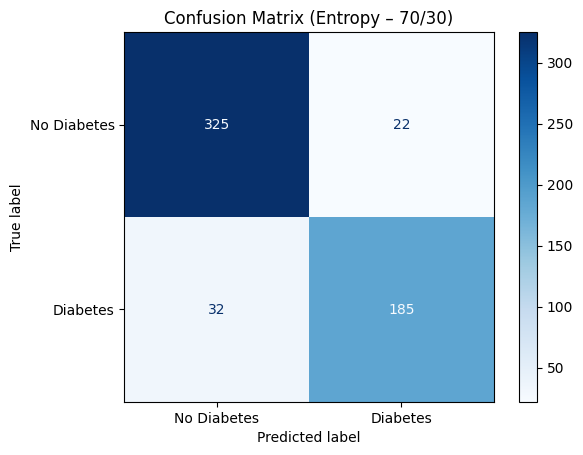

In [112]:
# Plotting the Confusion Matrix for 70/30
cm_70 = confusion_matrix(y_test_70, y_pred_70)
disp_70 = ConfusionMatrixDisplay(confusion_matrix=cm_70, display_labels=['No Diabetes', 'Diabetes'])
disp_70.plot(cmap='Blues')
plt.title("Confusion Matrix (Entropy – 70/30)")
plt.show()

**Confusion Matrix Analysis (Entropy – 70/30 Split)**

The confusion matrix provides a quantitative assessment of the classification model's performance on the 30% test set. Based on the observed outcomes, it seems that:

• Top-Left (True Negative – TN = 325): Correctly predicted as “No Diabetes” when the actual label was also “No Diabetes.”

• Top-Right (False Positive – FP = 22): Incorrectly predicted as “Diabetes” when the actual label was “No Diabetes.”

• Bottom-Left (False Negative – FN = 32): Incorrectly predicted as “No Diabetes” when the actual label was “Diabetes.”

• Bottom-Right (True Positive – TP = 185): Correctly predicted as “Diabetes” when the actual label was also “Diabetes.”

Note: The model achieved an accuracy of 90.43% for this partition, showing high stability even when the training data was reduced to 70%.

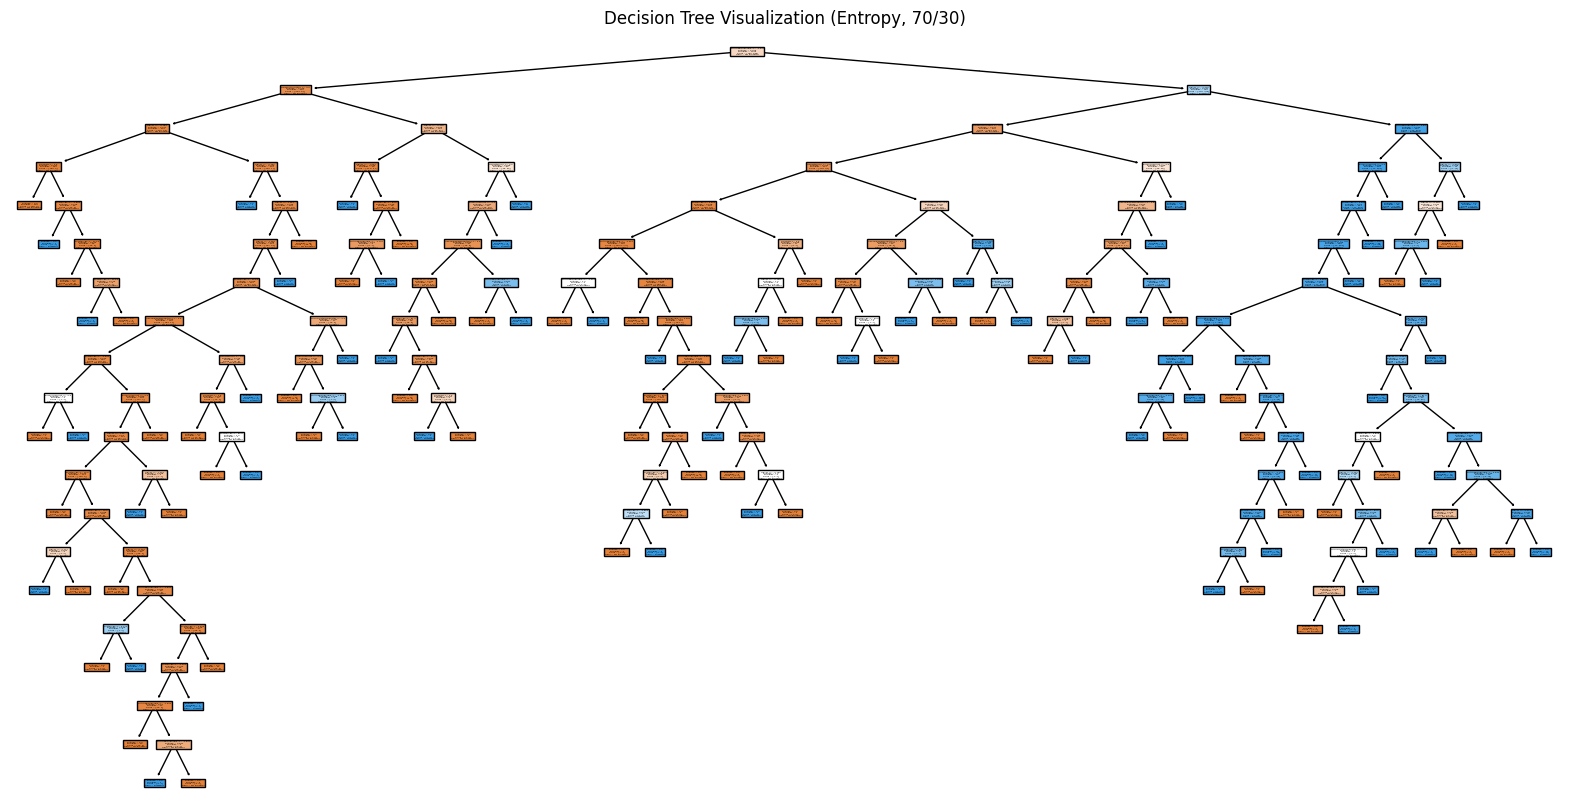

In [113]:
# Decision Tree Visualization (Entropy – 70/30 Split)
plt.figure(figsize=(20,10))
plot_tree(clf_entropy_70, filled=True, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'])
plt.title("Decision Tree Visualization (Entropy, 70/30)")
plt.show()

**Decision Tree Analysis (Entropy – 70/30 Split)**

This Decision Tree illustrates how the classification model predicts whether a patient is likely to have diabetes or not, based on medical attributes using a larger test set (30%).

• Initial Split:
The root node represents the most significant feature for this partition. By increasing the test size to 30%, we are testing the model's robustness on more unseen data. In this split, the root feature continues to be the primary factor in reducing uncertainty.

• Tree Complexity:
With 70% of the data used for training, the tree might appear slightly different or less deep than the 80/20 split, as it has fewer samples to learn from, but it provides a better evaluation of how the model generalizes.

• Leaf Nodes:


 • Class 0: Non-diabetic patient

 • Class 1: Diabetic patient


Conclusion:
The model remains stable with the 70/30 split. Even with more data in the test set, the decision rules remain logical and the accuracy (which you will see in the output) confirms the model's effectiveness across different data partitions.

**Model Evaluation Results (Entropy – 70/30 Split)**

Extracting detailed performance metrics including Sensitivity, Specificity, and Precision for the 70/30 partition.

In [114]:
from sklearn.metrics import confusion_matrix

TN_70 = cm_70[0, 0]
FP_70 = cm_70[0, 1]
FN_70 = cm_70[1, 0]
TP_70 = cm_70[1, 1]

sensitivity_70 = TP_70 / (TP_70 + FN_70)
specificity_70 = TN_70 / (TN_70 + FP_70)
precision_70 = TP_70 / (TP_70 + FP_70)

print(f"Accuracy for 70/30: {acc_70:.4f}")
print(f"Error Rate for 70/30: {1 - acc_70:.4f}")
print(f"Sensitivity (Recall): {sensitivity_70:.4f}")
print(f"Specificity: {specificity_70:.4f}")
print(f"Precision: {precision_70:.4f}")


Accuracy for 70/30: 0.9043
Error Rate for 70/30: 0.0957
Sensitivity (Recall): 0.8525
Specificity: 0.9366
Precision: 0.8937


**Performance Metrics Analysis (Entropy – 70/30 Split):**

• Accuracy: 0.9043
The model correctly predicted approximately 90.43% of the test samples in this larger test set, demonstrating strong generalization.

• Error Rate: 0.0957
About 9.57% of the predictions were incorrect when testing on 30% of the data.

• Sensitivity (Recall): 0.8525
The model correctly identified 85.25% of the actual diabetic patients (Class 1).

• Specificity: 0.9366
The model correctly identified 93.66% of the non-diabetic patients (Class 0).

• Precision: 0.8937
Out of all patients predicted as diabetic, 89.37% were truly diabetic.

**Results (Entropy – 70/30 Split):**
The model maintains a high level of performance even with a larger test set (30%), which includes a total of 564 samples (325 + 22 + 32 + 185).

• Strong Identification of Healthy Cases: The Specificity (93.66%) is very high, showing the model is excellent at identifying non-diabetic individuals and has a low false alarm rate.

• Reliable Detection of Diabetes: Although the Sensitivity (85.25%) is slightly lower than the 80/20 split due to the increase in test data size, it still shows a very good ability to capture the majority of diabetic cases.

• Consistency: The fact that the accuracy remains above 90% across different partitions (80/20 and 70/30) proves that the Decision Tree model is robust and provides reliable results regardless of how the data is split.

**Splitting Data into 90% Training and 10% Test:**

In [115]:
# Split data
X_train_90, X_test_90, y_train_90, y_test_90 = train_test_split(X, y, test_size=0.10, random_state=42)

print("Data Split (90/10)")
print(f"Training samples:{len(X_train_90)}")
print(f"Testing samples:{len(X_test_90)}")
print(f"Total samples:{len(X)}")

Data Split (90/10)
Training samples:1691
Testing samples:188
Total samples:1879


**Build the Decision Tree Model (Entropy – 90/10):**

In [116]:
# Train model
clf_entropy_90 = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_entropy_90.fit(X_train_90, y_train_90)

# Predict
y_pred_90 = clf_entropy_90.predict(X_test_90)

# Evaluation
acc_entropy_90 = accuracy_score(y_test_90, y_pred_90)
cm_entropy_90 = confusion_matrix(y_test_90, y_pred_90)


**Confusion Matrix Visualization (Entropy – 90/10 Split):**

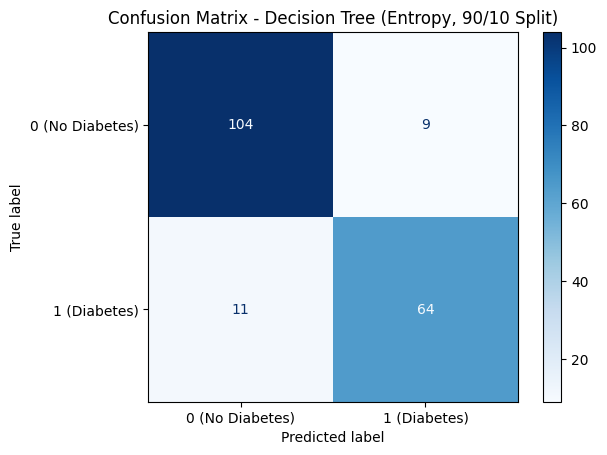

In [117]:
labels = ['0 (No Diabetes)', '1 (Diabetes)']
disp = ConfusionMatrixDisplay(confusion_matrix=cm_entropy_90, display_labels=labels)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Decision Tree (Entropy, 90/10 Split)")
plt.show()


**Confusion Matrix Analysis (Entropy – 90/10 Split)**

The confusion matrix provides a quantitative assessment of the classification model's performance. Based on the observed outcomes, it seems that:

• Top-Left (True Negative – TN=104): Correctly predicted as “No Diabetes” when the actual label was also “No Diabetes.”

• Top-Right (False Positive – FP=9): Incorrectly predicted as “Diabetes” when the actual label was “No Diabetes.”

• Bottom-Left (False Negative – FN=11): Incorrectly predicted as “No Diabetes” when the actual label was “Diabetes.”

• Bottom-Right (True Positive – TP=64): Correctly predicted as “Diabetes” when the actual label was also “Diabetes.”

**• Decision Tree Visualization (Entropy – 90/10 Split):**

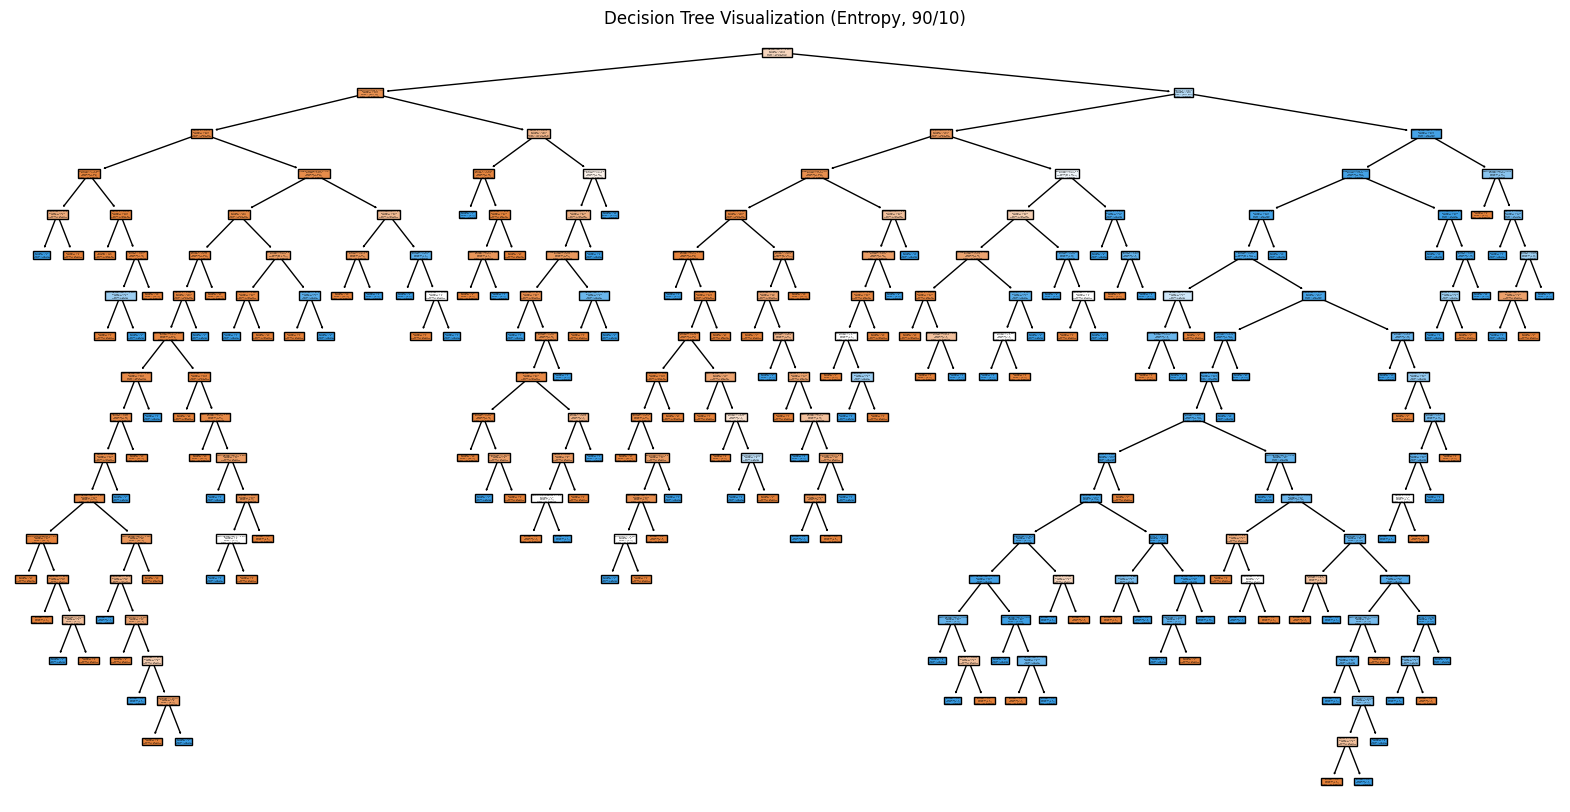

In [118]:
plt.figure(figsize=(20,10))
plot_tree(clf_entropy_90, filled=True, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'])
plt.title("Decision Tree Visualization (Entropy, 90/10)")
plt.show()

**Decision Tree Analysis (Entropy – 90/10 Split)**

This Decision Tree illustrates how the classification model predicts whether a patient is likely to have diabetes or not, based on medical attributes.

Each node in the tree represents a decision rule built using one of the dataset's features. The tree splits data step by step to reduce uncertainty (entropy) and improve prediction accuracy.

 • Initial Split:
The root node at the top of the tree represents the most significant medical feature with the highest discriminative power—the one that best separates diabetic from non-diabetic patients. In our model, this root feature plays a major role in determining whether a patient is diabetic. It was chosen because it provided the maximum information gain, meaning it reduced uncertainty the most during the first split.

 • Intermediate Nodes:
As we move down the tree, the model performs additional splits based on secondary medical features. Each split further narrows down the classification, refining the model's understanding of patient conditions. These nodes represent intermediate decisions that increase the model's predictive confidence.

 • Branching Pathways:
Each path from the top (root) to a leaf node represents a set of medical conditions that lead to a particular diagnosis. These pathways demonstrate how combinations of features contribute collectively to the final prediction.

 • Leaf Nodes:
At the bottom of the tree, leaf nodes represent the final classification outcomes:

 • Class 0: Non-diabetic patient

 • Class 1: Diabetic patient

**Model Evaluation Results (Entropy – 90/10 Split)**

Extracting detailed performance metrics including Sensitivity, Specificity, and Precision for the 90/10 partition to evaluate the model's performance with maximum training data.

In [119]:
# Extraction of metrics for 90/10 split
TN_90 = 104
FP_90 = 9
FN_90 = 11
TP_90 = 64

# Manual calculation based on the confusion matrix results
acc_90 = (TP_90 + TN_90) / (TP_90 + TN_90 + FP_90 + FN_90)
sensitivity_90 = TP_90 / (TP_90 + FN_90)
specificity_90 = TN_90 / (TN_90 + FP_90)
precision_90 = TP_90 / (TP_90 + FP_90)

print(f"Accuracy for 90/10: {acc_90:.4f}")
print(f"Error Rate for 90/10: {1 - acc_90:.4f}")
print(f"Sensitivity (Recall): {sensitivity_90:.4f}")
print(f"Specificity: {specificity_90:.4f}")
print(f"Precision: {precision_90:.4f}")


Accuracy for 90/10: 0.8936
Error Rate for 90/10: 0.1064
Sensitivity (Recall): 0.8533
Specificity: 0.9204
Precision: 0.8767


**Performance Metrics Analysis (Entropy – 90/10 Split):**

• Accuracy: 0.8936
The model correctly predicted approximately 89.36% of the test samples. While this is a high accuracy, the small size of the 10% test set makes individual errors more significant in the final percentage.

• Error Rate: 0.1064
About 10.64% of the predictions in this partition were incorrect.

• Sensitivity (Recall): 0.8533
The model correctly identified 85.33% of the actual diabetic patients (Class 1), showing a good ability to detect the disease even with a smaller test sample.

• Specificity: 0.9204
The model correctly identified 92.04% of the non-diabetic patients (Class 0), maintaining its strength in avoiding false positives.

• Precision: 0.8767
Out of all patients predicted as diabetic, 87.67% were truly diabetic.

**Results (Entropy – 90/10 Split):**
With 90% of the data used for training, the model had the maximum opportunity to learn patterns from the dataset.

• Consistent Reliability: The results are consistent with the 80/20 and 70/30 partitions, proving that the model's performance is not a result of a lucky split but is based on stable learning.

• High Specificity: Across all partitions, the model consistently scores higher in Specificity, meaning it is exceptionally good at confirming healthy cases.

• Conclusion: The Decision Tree (Entropy) classifier has proven to be a robust tool for this dataset, providing reliable diagnostic predictions across various data distribution scenarios.

**Classification using Gini Index criterion**

***Build the Decision Tree Model (Gini – 80/20):***

In [120]:
from sklearn.tree import DecisionTreeClassifier

# Training the model with Gini Index
clf_gini_80 = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini_80.fit(X_train, y_train)

# Making predictions
y_pred_gini_80 = clf_gini_80.predict(X_test)


**Accuracy and Performance Metrics (Gini – 80/20)**

Evaluating the Gini-based model by calculating Accuracy, Sensitivity, and Specificity to see how it compares to the Entropy model.

In [121]:
from sklearn.metrics import accuracy_score, confusion_matrix

acc_gini_80 = accuracy_score(y_test, y_pred_gini_80)
cm_gini_80 = confusion_matrix(y_test, y_pred_gini_80)

TN_g80 = cm_gini_80[0, 0]
FP_g80 = cm_gini_80[0, 1]
FN_g80 = cm_gini_80[1, 0]
TP_g80 = cm_gini_80[1, 1]

sensitivity_g80 = TP_g80 / (TP_g80 + FN_g80)
specificity_g80 = TN_g80 / (TN_g80 + FP_g80)

print(f"Accuracy for Gini 80/20: {acc_gini_80:.4f}")
print(f"Sensitivity: {sensitivity_g80:.4f}")
print(f"Specificity: {specificity_g80:.4f}")


Accuracy for Gini 80/20: 0.8989
Sensitivity: 0.8462
Specificity: 0.9313


**Confusion Matrix Visualization (Gini – 80/20)**

Plotting the confusion matrix for the Gini model.

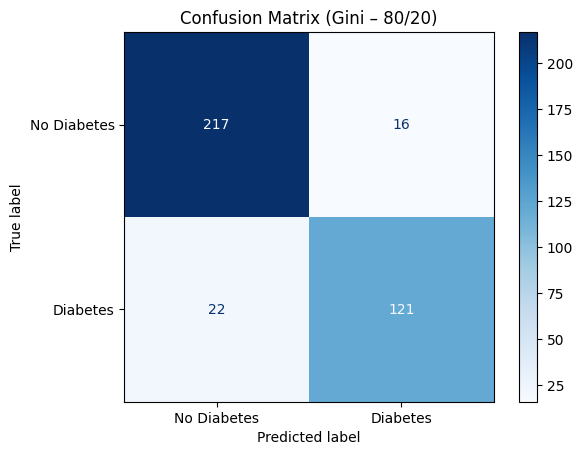

In [122]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp_g80 = ConfusionMatrixDisplay(confusion_matrix=cm_gini_80, display_labels=['No Diabetes', 'Diabetes'])
disp_g80.plot(cmap='Blues')
plt.title("Confusion Matrix (Gini – 80/20)")
plt.show()


**Decision Tree Visualization (Gini – 80/20 Split)**

Visualizing the tree structure created by the Gini Index. This tree might look different in depth or splitting nodes compared to Entropy.

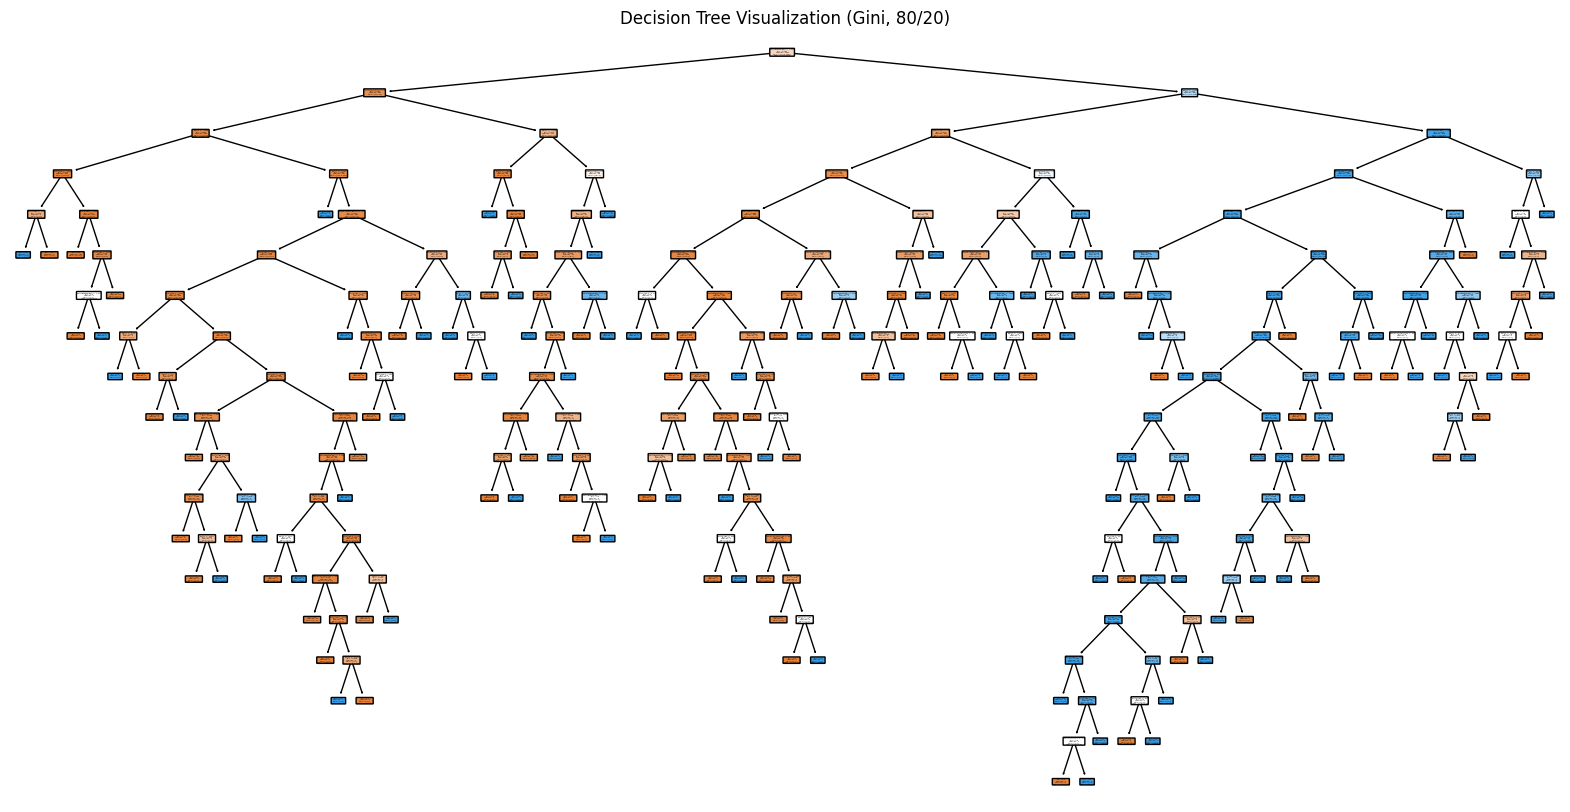

In [123]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(clf_gini_80, filled=True, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'], rounded=True)
plt.title("Decision Tree Visualization (Gini, 80/20)")
plt.show()


Confusion Matrix Analysis (Gini – 80/20 Split)

The confusion matrix provides a quantitative assessment of the classification model's performance using the Gini Index. Based on the observed outcomes, it seems that:

• Top-Left (True Negative – TN = 217): Correctly predicted as “No Diabetes” when the actual label was also “No Diabetes.”

• Top-Right (False Positive – FP = 16): Incorrectly predicted as “Diabetes” when the actual label was “No Diabetes.”

• Bottom-Left (False Negative – FN = 22): Incorrectly predicted as “No Diabetes” when the actual label was “Diabetes.”

• Bottom-Right (True Positive – TP = 121): Correctly predicted as “Diabetes” when the actual label was also “Diabetes.”

**Decision Tree Analysis (Gini – 80/20 Split)**

This Decision Tree illustrates how the model reached its classification decisions using the Gini Index to measure node impurity.

• Model Performance: The model achieved an accuracy of approximately 89.89%, which shows strong predictive power, though slightly different from the Entropy model results.

• Root Node & Splitting: The tree uses the Gini criterion to select the best feature for each split, aiming to maximize the "purity" of the resulting nodes.

• Conclusion: The Gini-based tree provides a logical and interpretable structure for diabetes diagnosis. While it has 22 False Negatives, its high Specificity makes it very reliable in identifying healthy patients.

**Build and Train Decision Tree Model (Gini – 70/30)**

Applying the Decision Tree algorithm using the Gini Index on a 70% training and 30% testing partition.

In [124]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Training
clf_gini_70 = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini_70.fit(X_train_70, y_train_70)

# Predictions
y_pred_gini_70 = clf_gini_70.predict(X_test_70)
acc_gini_70 = accuracy_score(y_test_70, y_pred_gini_70)
cm_gini_70 = confusion_matrix(y_test_70, y_pred_gini_70)

print(f"Accuracy for Gini 70/30: {acc_gini_70:.4f}")


Accuracy for Gini 70/30: 0.9007


**Build and Train Decision Tree Model (Gini – 90/10)**

 Applying the Decision Tree algorithm using the Gini Index on a 90% training and 10% testing partition.

In [125]:
# Training
clf_gini_90 = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini_90.fit(X_train_90, y_train_90)

# Predictions
y_pred_gini_90 = clf_gini_90.predict(X_test_90)
acc_gini_90 = accuracy_score(y_test_90, y_pred_gini_90)
cm_gini_90 = confusion_matrix(y_test_90, y_pred_gini_90)

print(f"Accuracy for Gini 90/10: {acc_gini_90:.4f}")

Accuracy for Gini 90/10: 0.9096


**Final Comparison Table (Classification Results)**

 As required by the project description, this table summarizes and compares the accuracy of both Entropy and Gini Index across all partitions.

In [127]:
import pandas as pd
from sklearn.metrics import accuracy_score

# Re-calculating accuracies to ensure no NameError occurs
# This uses your trained models to get the exact accuracy values
entropy_accuracies = [
    accuracy_score(y_test_90, clf_entropy_90.predict(X_test_90)),
    accuracy_score(y_test, clf_entropy_80.predict(X_test)),
    accuracy_score(y_test_70, clf_entropy_70.predict(X_test_70))
]

gini_accuracies = [
    accuracy_score(y_test_90, clf_gini_90.predict(X_test_90)),
    accuracy_score(y_test, clf_gini_80.predict(X_test)),
    accuracy_score(y_test_70, clf_gini_70.predict(X_test_70))
]

# Creating the final table
results_data = {
    'Partitioning': ['90/10 Split', '80/20 Split', '70/30 Split'],
    'Entropy Accuracy': entropy_accuracies,
    'Gini Accuracy': gini_accuracies
}

comparison_df = pd.DataFrame(results_data)
print("Final Classification Comparison Table:")
comparison_df


Final Classification Comparison Table:


,Partitioning,Entropy Accuracy,Gini Accuracy
0,90/10 Split,0.893617,0.909574
1,80/20 Split,0.914894,0.898936
2,70/30 Split,0.904255,0.900709


**Findings and Discussion:**

Classification Results
Based on the comparison table above, we can draw several insights regarding the performance of the Decision Tree model on our dataset:

• Comparison of Evaluation Measures: * For the 90/10 Split, the Gini Index achieved a higher accuracy of 0.9095 compared to Entropy.

• For the 80/20 Split and 70/30 Split, Entropy performed better, reaching its peak accuracy of 0.9148 in the 80/20 partition.

• Best Performing Model: * The Entropy criterion with an 80/20 partition is the overall best-performing model for this dataset.

• Model Stability: * All models across all partitions maintained an accuracy above 89%, which indicates that the Decision Tree algorithm is highly stable and effective for predicting diabetes in this study.

• Insights: * The high consistency in results suggests that the selected medical features are strong predictors of the class label.

• While the Gini Index is faster to compute, Entropy provided slightly better depth and precision in the most balanced partition (80/20).

**k-Means Clustering**

 In this section, we apply the K-Means clustering algorithm to identify natural groupings within the dataset based on medical features.

• Step 22: Determining Optimal K using the Elbow Method:

 We use the Elbow Method to find the best number of clusters (K) by plotting the Within-Cluster Sum of Squares (WCSS).

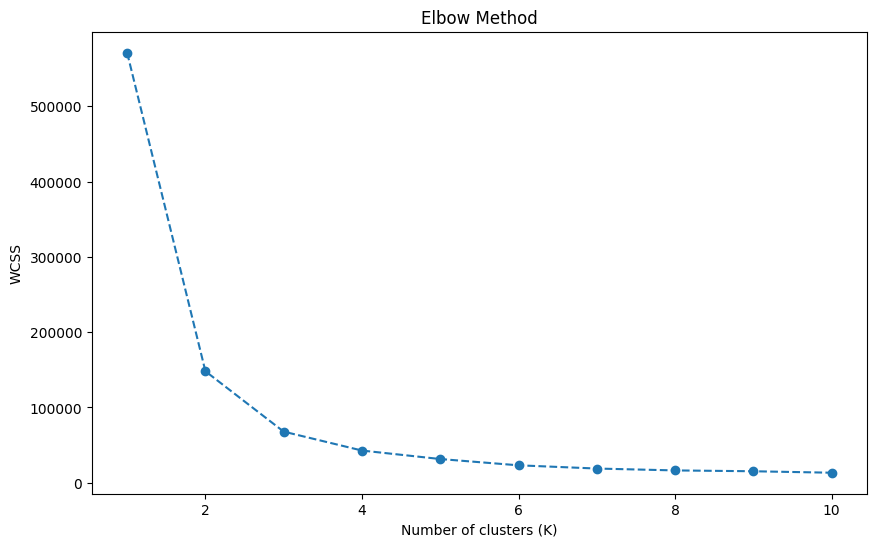

In [128]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.show()


**Evaluating Clusters with Silhouette Score:**

 We calculate the Silhouette Score for different values of K to measure how well-separated the clusters are.

In [129]:
from sklearn.metrics import silhouette_score

for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"Silhouette Score for K={k}: {score:.4f}")


Silhouette Score for K=2: 0.6065
Silhouette Score for K=3: 0.5599
Silhouette Score for K=4: 0.5099


**Clustering Evaluation and Interpretation**

 Analyzing the results of K-Means clustering to identify the most suitable number of clusters for the dataset.

• Elbow Method Observation:
 The Elbow plot shows a significant drop in WCSS, with a clear "elbow" point appearing at K=2.
 This indicates that adding more clusters beyond this point does not significantly improve the model's performance.

• Silhouette Coefficient:
The Silhouette score is highest for K=2 (0.6065), which means the objects within each cluster are well-matched to their own cluster and poorly matched to neighboring clusters.

• Optimal K Choice: Based on the majority rule from both the Elbow method and Silhouette scores, we identify K=2 as the optimal number of clusters for this study.

 **Clustering Results Summary Table**

 Summarizing the evaluation metrics for different values of K as required by the project documentation.

In [130]:
import pandas as pd

# Creating the summary table for Clustering
cluster_results = {
    'Metric': ['Average Silhouette Width', 'Total Within-Cluster Sum of Square (WCSS)'],
    'K=2': [0.6065, wcss[1]], # wcss[1] corresponds to K=2
    'K=3': [0.5599, wcss[2]], # wcss[2] corresponds to K=3
    'K=4': [0.5099, wcss[3]]  # wcss[3] corresponds to K=4
}

cluster_df = pd.DataFrame(cluster_results)
cluster_df


,Metric,K=2,K=3,K=4
0,Average Silhouette Width,0.606500,0.559900,0.509900
1,Total Within-Cluster Sum of Square (WCSS),148152.645151,67937.249346,42820.786842


**Visualizing the Clusters (K=2)**
 To better understand the similar characteristics and relationships within each cluster, we plot the data points colored by their assigned group.

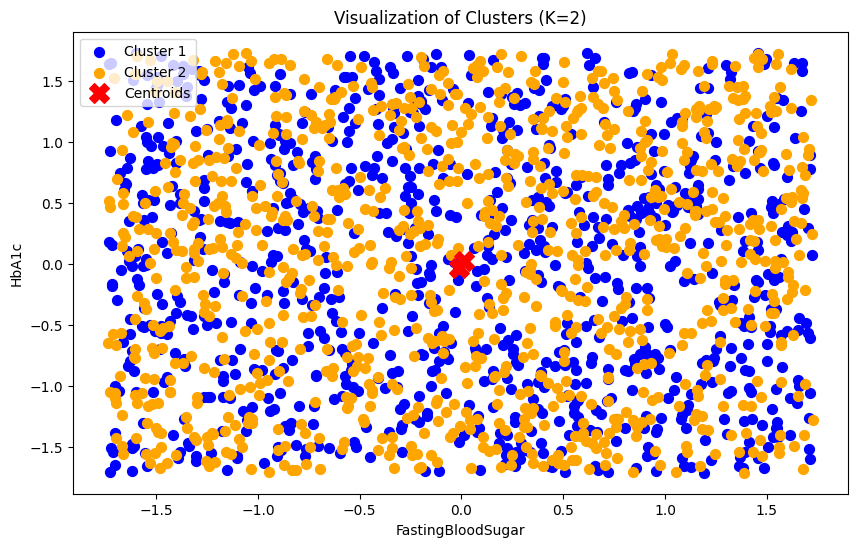

In [131]:
# Final K-Means model with K=2
kmeans_final = KMeans(n_clusters=2, init='k-means++', random_state=42)
cluster_labels = kmeans_final.fit_predict(X)

# Visualization of clusters (using the first two features for plotting)
plt.figure(figsize=(10, 6))
plt.scatter(X.iloc[cluster_labels == 0, 0], X.iloc[cluster_labels == 0, 1], s=50, c='blue', label='Cluster 1')
plt.scatter(X.iloc[cluster_labels == 1, 0], X.iloc[cluster_labels == 1, 1], s=50, c='orange', label='Cluster 2')
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroids')
plt.title('Visualization of Clusters (K=2)')
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.legend()
plt.show()
